# Exercise project 1


### <i>Dataset evaluation report </i>

<i>Nihar Buha</i>

---

### Summary

|Topic               |Description               |
|--------------------|--------------------------|
|Dataset Name:       |  Adult census income                        |
|Dataset Link:       | https://www.kaggle.com/datasets/uciml/adult-census-income                         | 
|Target Variable:    |  income                        | 
|Type of Dataset:    | Classification|

<br>



---


## Overview

<br>
<br>

##### <b> <u>Step 1a</u>: Inspect the datatypes for each column </b> 

<i>
<strong style='color:orange ; background-color:black;'>Fix these before continuing below.</strong>


Some visuals require numeric/datetime columns (heatmaps, matrices, etc). Most common problem is date-columns being in string/object -format => change to DateTime -objects.
</i>

<i>Easiest option is probably to use pandas' dtypes-feature.</i>


<br><br>
<br>

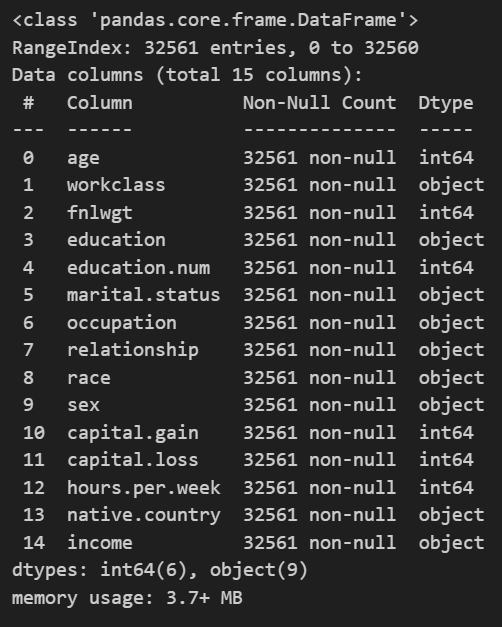

##### <b> <u>Step 1b</u>: Inspect the shape of the dataset (the number of rows and columns.) </b> 

<i>


How many rows and columns are in your dataset? 

Are you expecting any issues if you were to train a model with this amount of rows/columns?

Justify your answer. Provide visuals if needed.

<br>

<u><b>Hint:</b></u> ydata-profiling, pandas.shape()

</i>

<br><br>
<br>

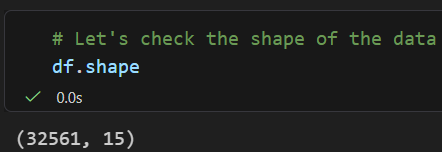

* I have 32561 rows and 15 columns in my dataset. I do not think there should be any problem with these amount of rows and columns because the datset that I have selected has enough data for the model to be trained and I have cleaned and trained the model with these dataset earlier too.

Number of variables	15<br>
Number of observations	32561

##### <b> <u>Step 1c</u>: Inspect NaN values, duplicates, zeroes, invalid/nonsensical/problematic values </b> 

<i>
How many missing values are there? 
<br>

How many duplicate values are there? 

Are there any abnormal amounts of zeroes?

Are there any values which don't make sense or don't belong there?

Please explain how each of these values in your dataset might or might not be problematic.

<br>

<u><b>Hint:</b></u> ydata-profiling, pandas


</i>

<br>
<br>

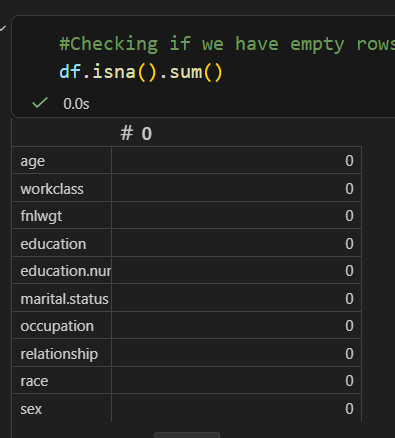

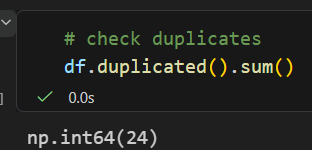

Missing Vlaues: None<br>
Duplicate Values: 24<br>
Abnormal Amt Zeros: None<br>

* There were 24 duplicates in the dataset which were removed.

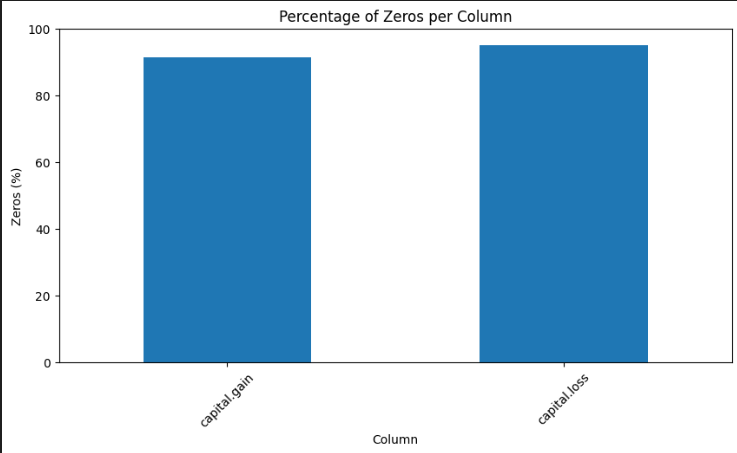

* capital.gain and capital.loss show an unusually high amount of zeros - ~ 91 and ~ 95 respectively. Researching about this I found that this is not a data error. Zero legitimately means the person had no gapital gain/loss that year, which is expected for most people. 

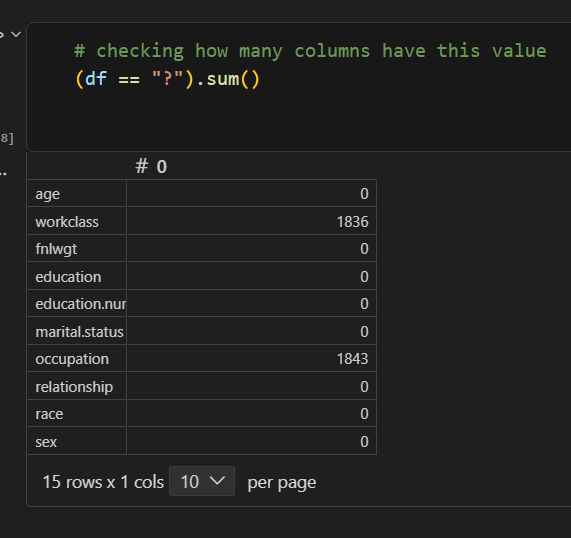

 Looking at df I found that three columns have this particular value "?". 

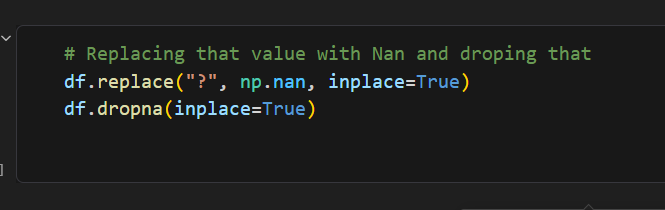

So, I replaced it with NaN value and than droped it.

##### <b> <u>Step 1d</u>: Are there any alerts recommendations?</b> 

<i>
When you used a big-picture tool(s), what kind of alerts did it give you? Were they valid concerns?

<br>

Justify. If possible, please show a visual.

<br>

<u><b>Hint:</b></u> ydata-profiling, SweetViz, AutoViz, dataprep etc.
</i>

<br>
<br>

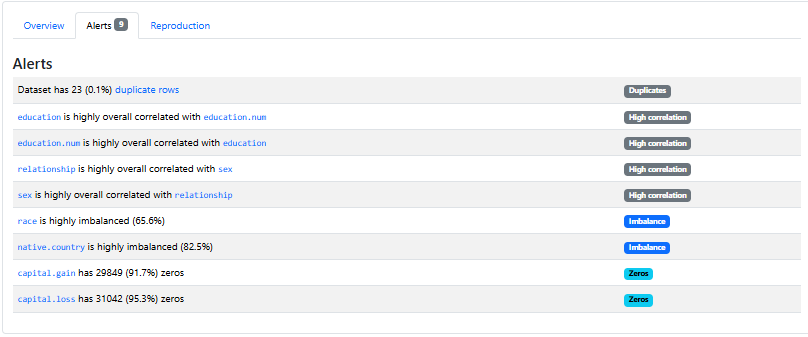

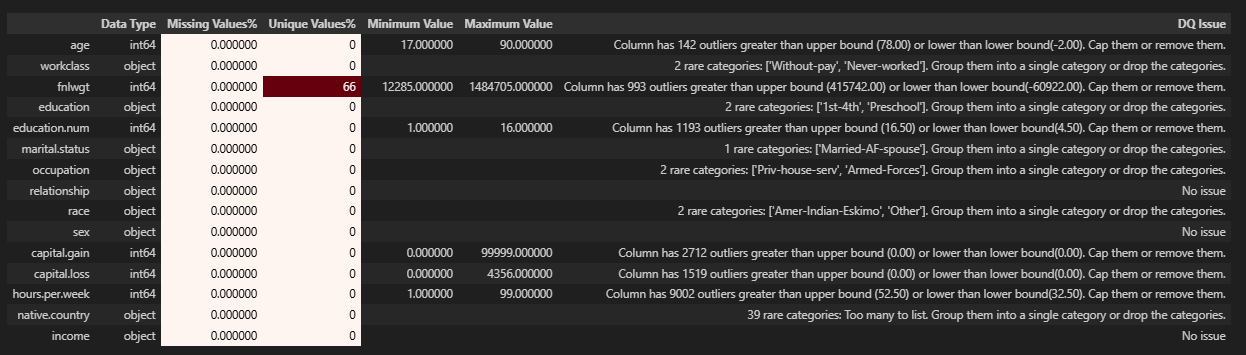

* Duplicates - Already identified and removed in step 1c

* High correlation - education <> education.num, relationship <> sex

This is the same information in two forms. One of them, likely education should be dropped.
relationship and sex are correlated because some relationship categories are geneder-specific. This is real but structural dependecy rather than pure redundancy, since relationship also carries info sex doesn't. Will be investigated in step 2b.

* Imbalance - race (65.6%), native.country (82.5%)

Both reflect the real demographic patterns in US census sample (majority white, majority US-born) rather than real data error. Valid finding - will monitor during training the model as minority categories have few examples and a model may struggle to learn the patterns, also raises the fairness question as the target value is income. No fixation here, will investigate in step 2a. 

* Zeros - capital.gain (91.7%), capital.loss (95.3%)

Already discussed in step 1c

* "Outliers" in capital.gain/capital.loss and hours.per.week (Autoviz)

This alert is misleading and therfore not acted upon.
The capital gain/loos columns have 90% of its values to be 0, the IQR fails and thefore flags any non-zero values to be an 'outlier'
Similarly, hosrs.per.week flagged 30% as outliers for working more/less than 32.5-52.5 hours, but part-time and overtime work are normal, expected variation, not data errors.

* Rare categories - workclass, education, marital.status, occupation, race, and especially native.country (39 rare categories)

These are legitimate small-sample categories, not errors. Valid finding, especially native.country, will be explored further in step 2c

---

## Distribution, outliers, imbalances

<br>
<br>

##### <b> <u>Step 2a</u>: Distributions & imbalances</b> 

<i>
Inspect the distribution for the target variable and its features. 
<br>

Which columns may have distributions which are problematic for machine learning? 
<br>

For each problematic column, describe what kind of problems they exhibit (for example: left-skewed, right-skewed, high kurtosis, low kurtosis).

Do you expect this will be an issue when training ML models? Justify your answers. Please introduce visuals.

 <br>

<u>OPTIONAL:</u> 

Q-Q plots. Another way to visualize distributions is using Q-Q plots. 

These are particularly good for identifying thin/thick-tailed distributions and are an alternative to histograms. 

Do these phenomena exist in your dataset?  

<br>

<u><b>Hint:</b></u> ydata, SweetViz, Dtale, pandas…



</i>


<br><br>
<br>

### Target Variable Distribution

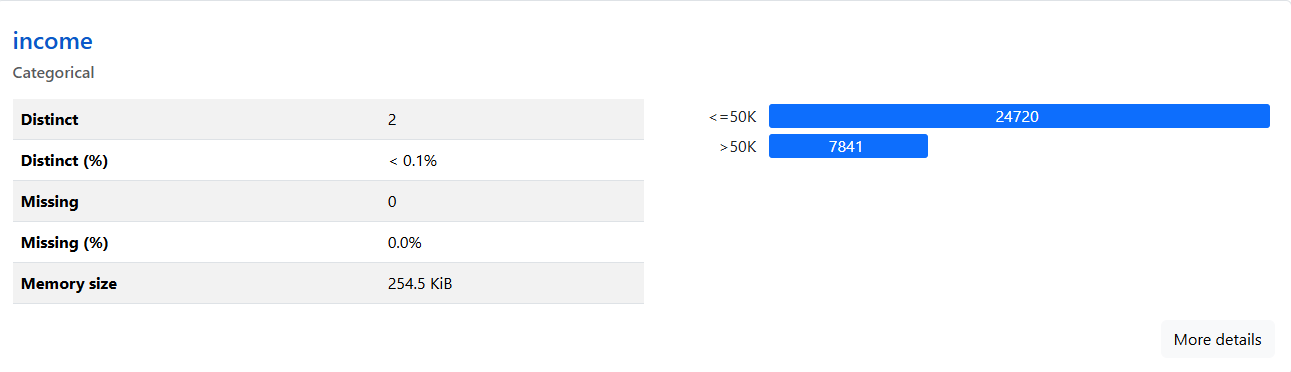

~75 <=50K vs ~25 >50K - moderate class imbalance. Unlike the regression project, this directly affects the model evaluation. A model predicting the majority class every time would score 75% accuracy without learning anything, so accuracy alone will be a misleading metric for this model. precision/recall/F1 or stratified sampling will be needed.

### Variables

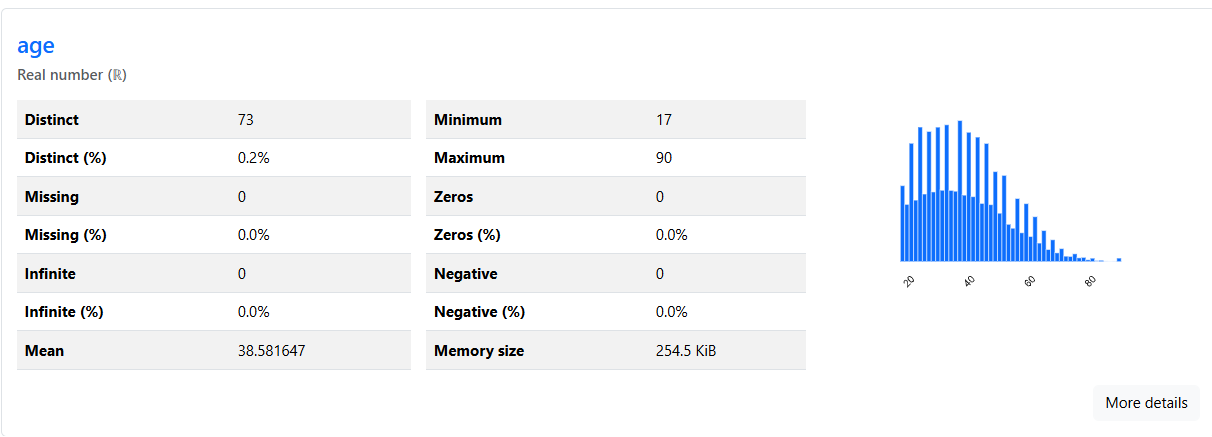

Mild right skew (0.53), roughly normal spread from ~17-90. Not problematic, fine for modeling.

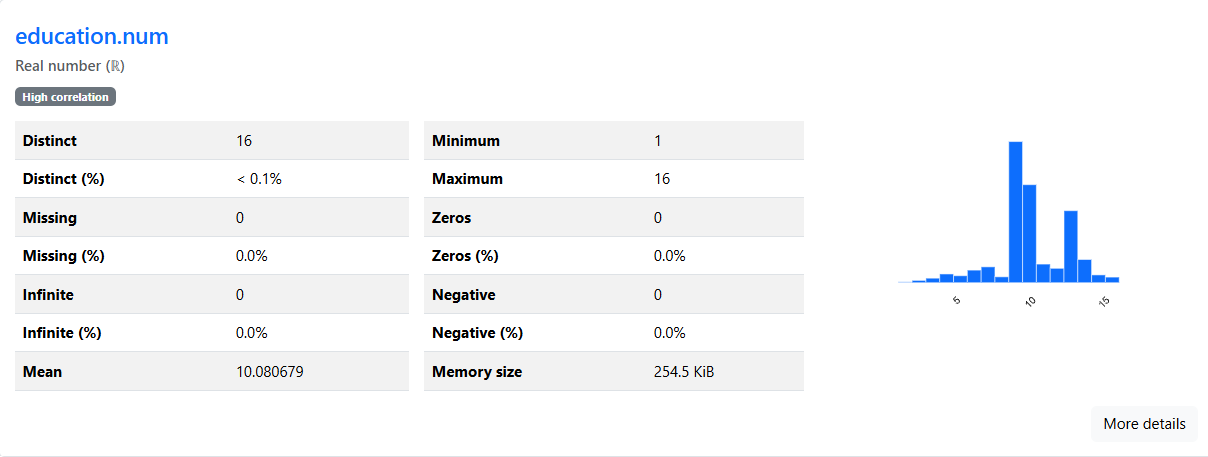

Roughly symmetric (skew -0.30), no real issue

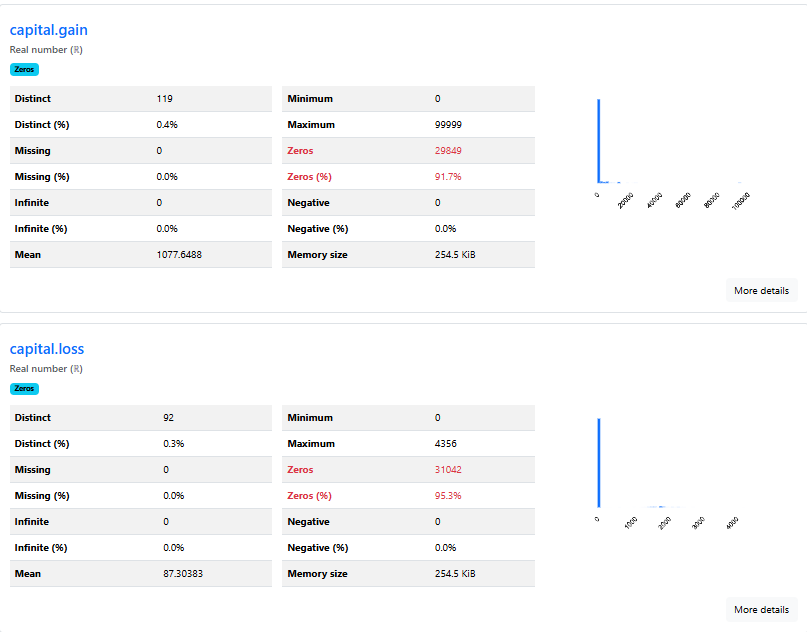

Extreme right skew  and extreme kurtosis, by far two most extreme columns in the dataset. Directly caused by the ~92% zero concentration already mentioned in 1c/1d. Likely needs special handling rather than plain scaling.

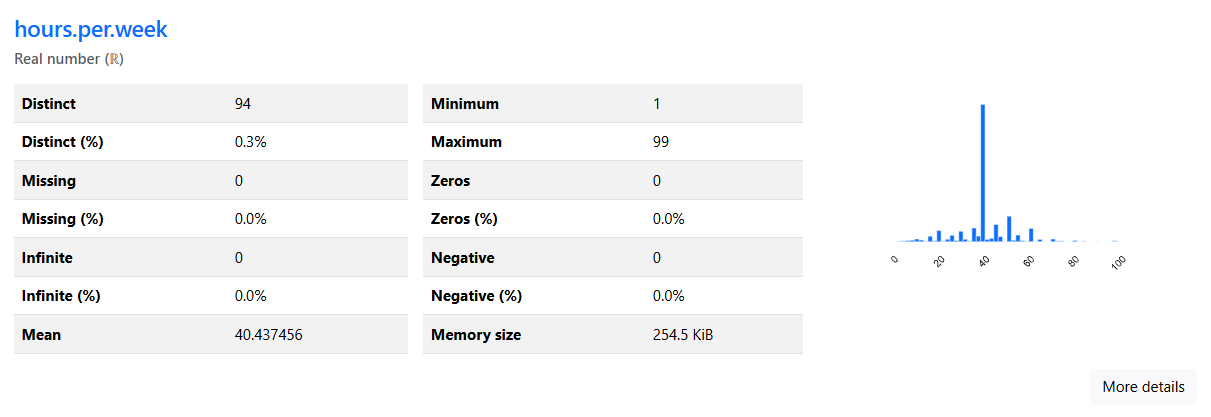

Mild skew (0.33), moderately peaked around 40 (standard work week). Not a major concern.

* race, native.country and sex columns imbalance and cause has already been mentioned in step 1c/1d

##### <b> <u>Step 2b</u>: Multicollinearity & redundancy </b> 

<i>
Some columns may prove to be redundant to others -- Or even worse, they give away the answer entirely.
    <br>

Are there any columns which are redundant and/or suggest high multi-collinearity? 

Which tool(s)/test(s) have you performed to come to this conclusion? 

Justify your answer and, if possible, produce your results as an image below.

<br>

<u><b>Hint:</b></u> VIF test, Correlation Matrix, Phik-matrix, RFE etc.

</i>


<br>
<br>
<br>

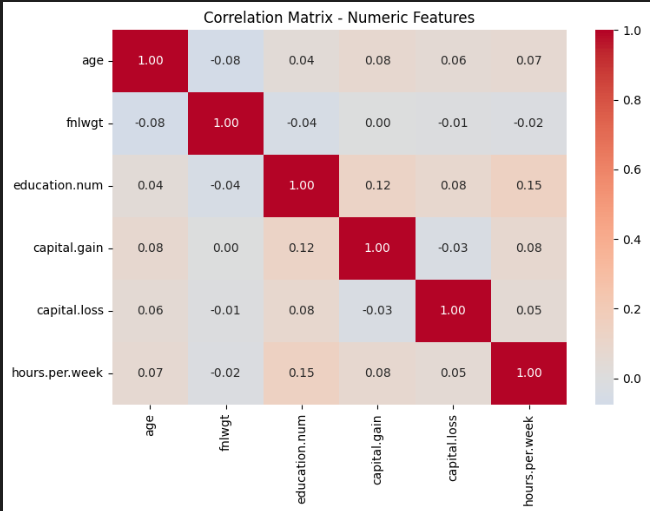  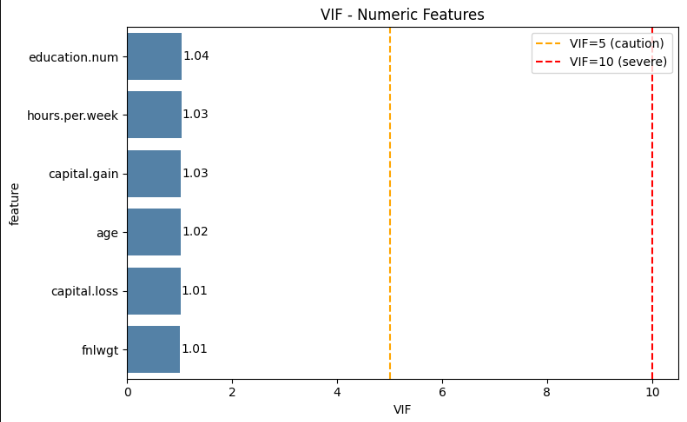

* The Pearson correlation matrix and VIF test showed no multicolinearity among the numerical columns such as age, fnlwgt, education.num, hours.per.week, capital.gain and capital.loss. Unlike the regression project, these features are genuinely indepenent of each other.  

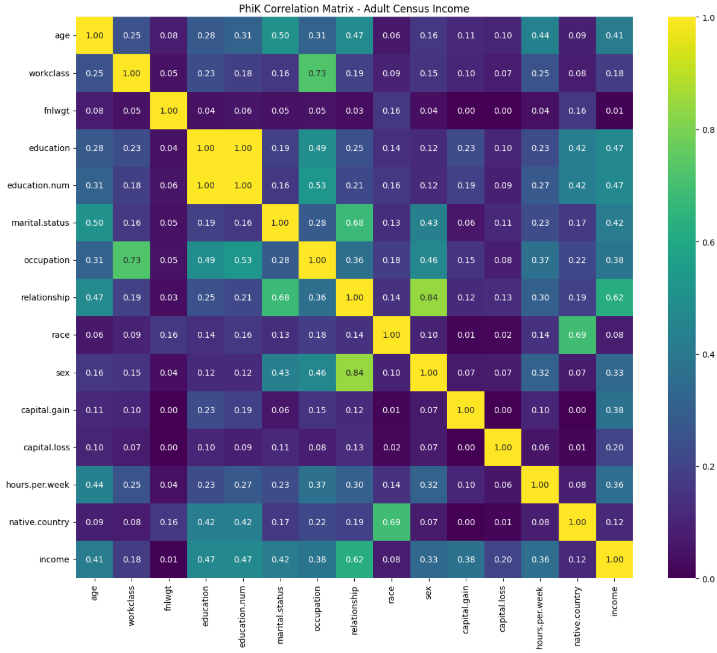

* However, the Phik showed the redundancy which pearson and VIF could not. education <> education.num (1.00, perfect duplicate), relationshi <> sex (0.84) and relationship <> marital.status (0.68) - all describing overlapping personal/family attributes, and race <> native.country (0.71), reflecting the dataset's demographic skew. occupation also shows moderate overlap with several columns (workclass, sex, education). Before modeling, the columns which can be removed should be one of education/education.num, should check whether relationship, martial.status, and sex all been kept given their mutual overlap. fnlwgt variable shows almost no correaltion with any column in the dataset, including the target, confirming that this is a sampling artifact rather than a meaningful predictor.

##### <b> <u>Step 2c</u>: High cardinality</b> 

<i>
Inspect each categorical column for high-cardinality (high percentage of unique values in the dataset). 

<br>

Which columns, if any, contain an unusual or problematic amount of unique values?  Which tool(s) or method(s) did you use to come to this conclusion? 

Justify your answer and, if possible, produce the output as a visual.

<br>

<u><b>Hint:</b></u> Big picture tool like ydata-profiling, pd.value_counts()

</i>


<br>
<br>
<br>
<br>

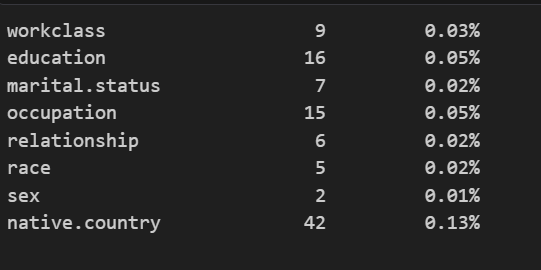

* All the categorical columns in the dataset has low or moderate cardinality except native.country, which has 42 unique values and certainly high cardinality.

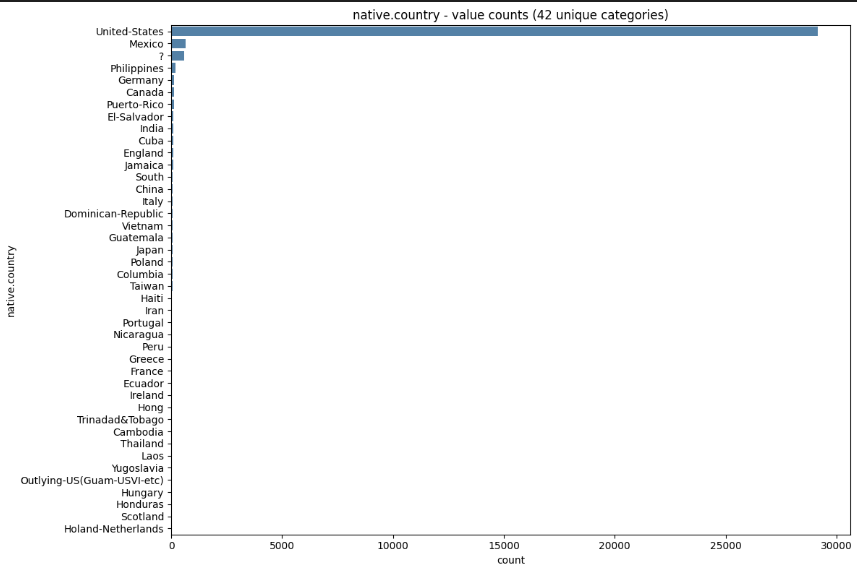
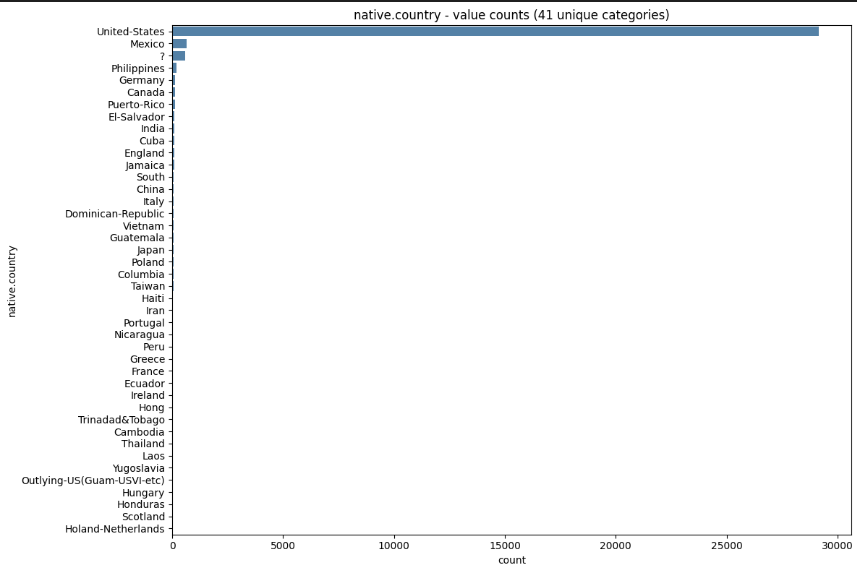

* Inspected the categories of native.country. We can observe that United-States alone accounts for 27,487 of 30,139 rows (~ 91%), and the remaining ~2650 rows are split across 41 other countries, many with fewer than 20 observations each. I am planning to create a binary column from this like: is_US/is_foriegn_born or something like that as we can see how dominant the US category is. Also, this column has vey correlation with the target variable, so it is safe to take the action.

---

## Overlapping, noise, and correlation/associations

<br>
<br>

##### <b> <u>Step 3a</u>: Major trends</b> 

<i>
After inspecting the trends between your target variable and its features -- Are you noticing anything interesting?
<br>

 Any surprising positive or negative trends?
 
  Any evidence of noise (jittering)?
  
Are your interesting columns linear or non-linear?

Is there anything that 'breaks the rules' of the trend?
 
Please provide visuals of which major trends you found interesting and worthy mentioning.

Hypothesize and, if necessary, research online why this irregular trend occurs.

Also, provide which tool(s) you have used to inspect this aspect of your dataset.

<br>

<u><b>Hint:</b></u> regression plots/scatterplot/pairplot, correlations/phik-matrix/associations, feature importance tools ...

</i>


<br>
<br>
<br>

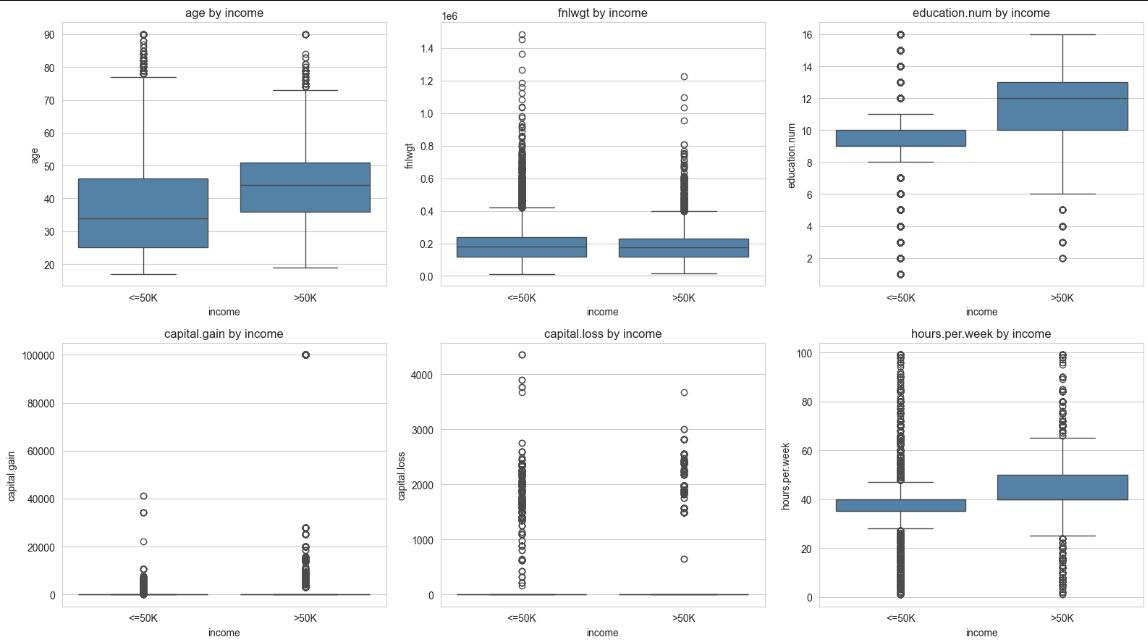

* Age - A separartion is visible: >50K earners have visibly higher median age than <50K. Makes sense as carrier progression takes time

* fnlwgt - Nearly identical distribution/median, confirming the phik findings that these particular column has no correlation with the income.

* education.num - Also a clean, strong separation. Expected as more educations > higher pay.

* hours.per.week - >50K earners work more hours, expected.

* Capital gain/loss - Both still dominated by the zero-heavy pattern in both groups, but the >50K group clearly has more of the non-zero high values (visible as more/higher outlier dots). This is the kind of relationship that doesn't show up well in a boxplot because of the zero-concentration - limitation of this particular visual for these two columns specifically

##### Linear or non-linear?


age, education.num, hours.per.week shows a linear trend with income, capital gain/loss are non-linear (here I think binary matters more than the amount). relationship/martial.status are purely categorical, not linear at all.

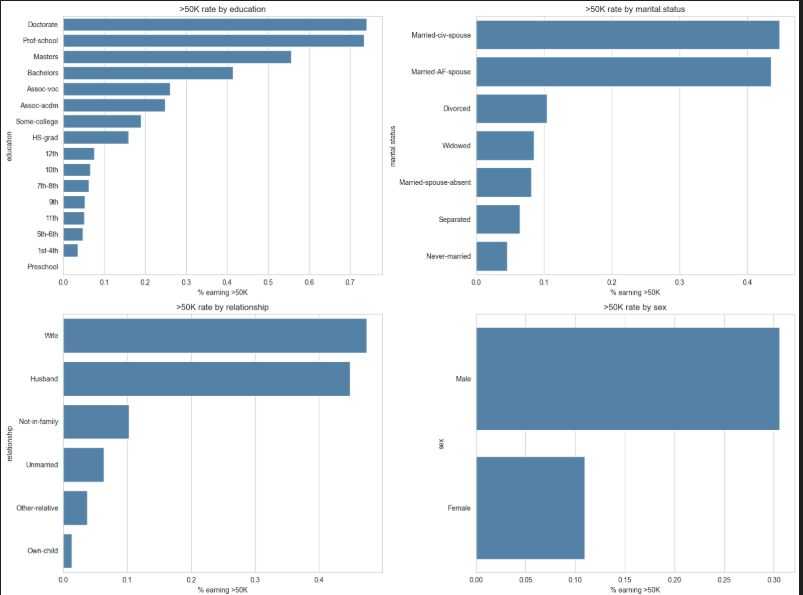

* education - Clean, staircase pattern, >50K rate raises steadily from preschool upto Prof-school/Doctrate. This is the cleanest trend in the dataset.

* martial.status - "Married-AF-spouse" and "Married-civ-spouse" have relatively far better position than other categories in the column

* relationship - "Husband" and "Wife" earns >50K far more often than "Own-child" or "Other-relative". This also overlap heavily with martial.status (confirming the correlation matrix), worth noting as these two are telling very similar story, not two independent trends.

* sex - Males earn >50K at roughly 3x the rate of females (31% vs 11%) - a striking gap that likely reflects historical income inequality in the data's source period rather than a data error, and is worth flagging as a fairness consideration if this feature (or variables like relationship, which correlates 0.84 with sex) is used in a predictive model.

#### "Break the rules"

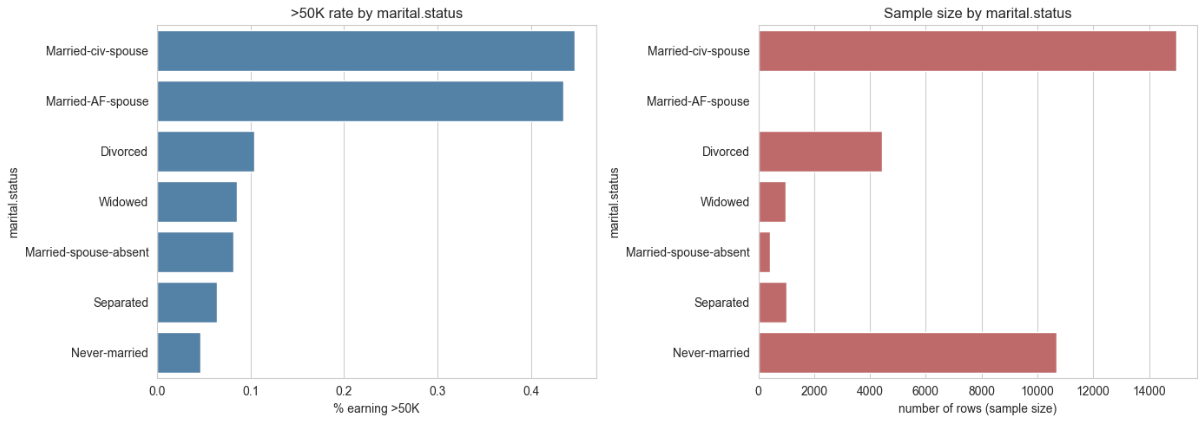

* Married-AF-spouse shows the seconmd highest >50K rate of category, which could look like an intersting trend. However, this category has only 21 rows, so the percentage is based on roughly 10 people earning more than >50K, too small sample to draw a conclusion from. 

##### <b> <u>Step 3b</u>: Overlapping Data</b> 

<i>
Does any overlapping exist between the features and your target variable?
<br>

Do you expect this to be an issue if you were to train a model with this data?

Justify your answer and, if reasonably possible, provide visuals.

Also, provide which tool(s) you have used to inspect this aspect of your dataset.

<br>

<u><b>Hint:</b></u> seaborn box-/scatterplots
</i>

<br><br>
<br>

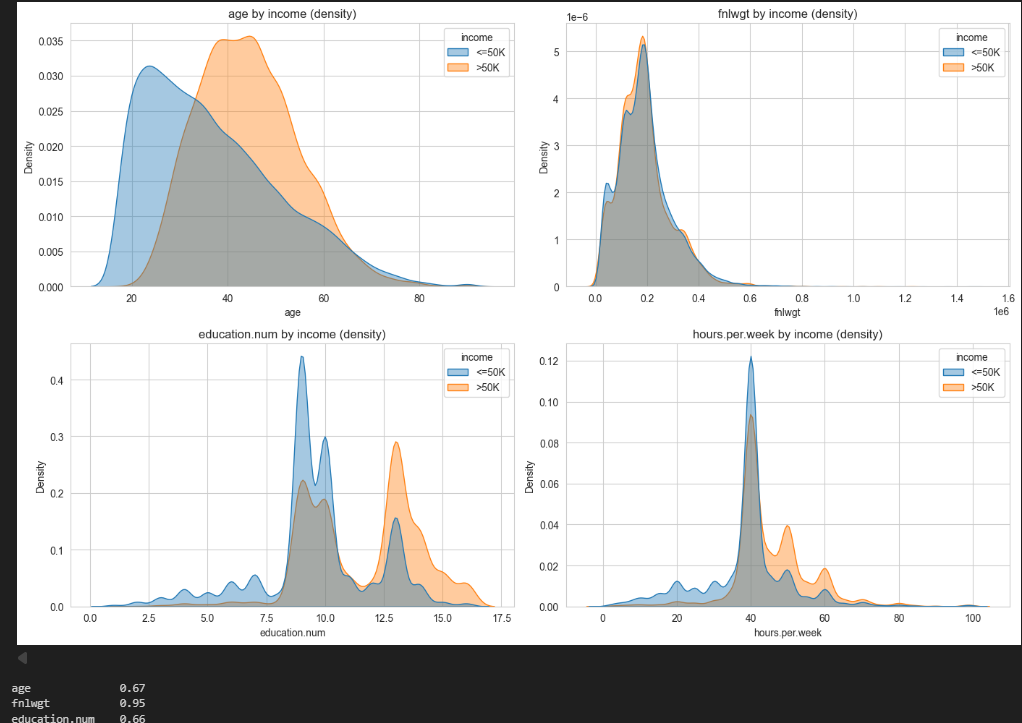

Note: I asked AI is there any other than box/scatter plots to see the overlap. It told me that density plots also provide good visuals, therefore using it.

* Overlap between the certain calsses was seen through overlaid density plots plus an overlap coefficiant. fnlwgt shows near total overlap (0.95), so it cannot help distinguish income classes. hours.per.week (0.74), age (0.68) and education.num (0.67) overlap moderately. education.num is one of the most separable numeric features of these, having a second peak at 13(bachelors) for >50K earners. For categorical features, realtionship, martial.status and education show strong separation(look at 3a charts). Some overlap is expected and should not stop a model from learning, because the features are still informative in combination. The exception is fnlwgt, which shows almost no separating information.

##### <b> <u>Step 3c</u>: Outliers & noise</b> 

<i>
Inspect each categorical column for potential outliers and noise. 

<br>

<u>For each column with noise:</u>

In which columns are you detecting noise? Which tool(s) or method(s) did you use to find this?


<u>For each column with outliers:</u>

Are you seeing many outliers in your columns? How extreme (in your opinion) are the outliers? How problematic do you expect this to be if these outliers remained in the dataset? Which tool(s) or method(s) did you use to find this?


<u><b>Hint:</b></u> Isolation Forest, IQR, z-score, Elliptic Envelope, MAD...




</i>


<br>
<br><br>

Note: I was bit more confused with using this tools and understanding tghe results and therefore I used AI first to understand how to use these tools and how to understand the results. I also asked it generate me the code.

#### MAD

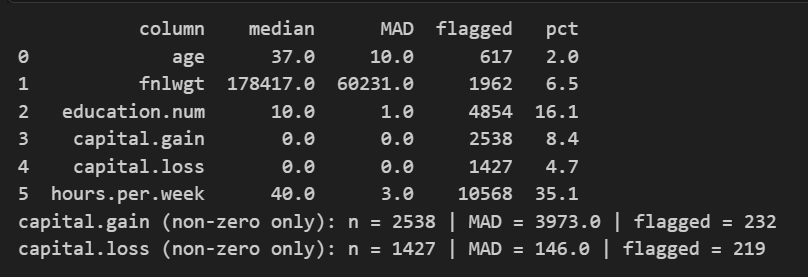

#### Isolation forest

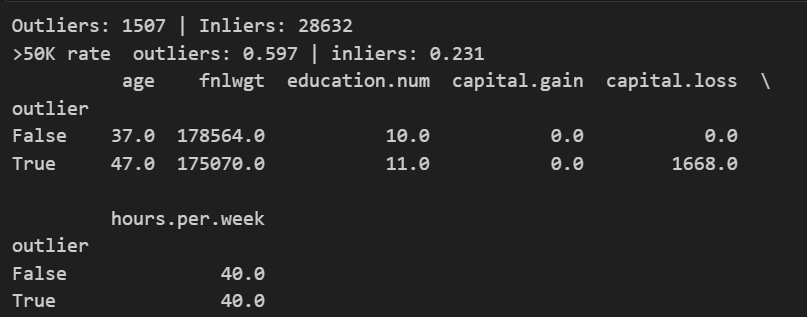

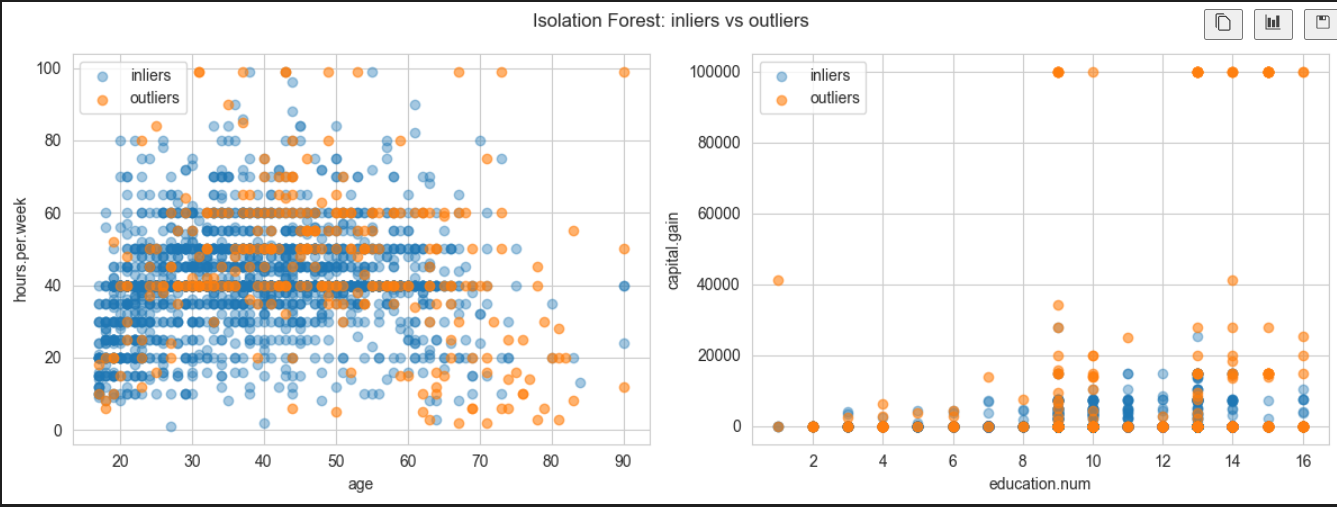

* Outliers - I used MAD and Isolation forest. MAD flags 2% of age and 6.5% of fnlwgt, which are plausible values. It over-flags education.num (16%) and hours.per.week (35%) because those values are bunched together. Isolation Forest (5% contamination) flags 1,507 rows. They are mostly large capital gains or losses and are >50K 60% of the time (vs 23%), so they carry signal. I keep all rows.

* Noise - capital.gain and capital.loss are 91% and 95% zeros, so their MAD is 0 and every non-zero value is flagged. This is a mechanical problem, not an error. On non-zero rows, MAD flags 232 gains and 219 losses. capital.gain also has 148 rows at exactly 99,999, a likely cap, all >50K. I will use a has-gain / has-loss flag instead of the raw amounts.

##### <b> <u>Step 3d</u>: Correlations & associations</b> 

<i>
Inspect the Phi-K and Correlations matrix.

<br>

What kind of linear relationships are you detecting that correlate with your target variable?
 
What kind of non-linear relationships are you detecting that associate with your target variable?

Do you suspect any noise and/or multi-collinearity from these results?

Are there any other interesting things you found?

Justify your answer and provide visuals of the output of both the phi-k and correlation matrix.

<br>

<u><b>Hint:</b></u> Phik/pd.corr + heatmap, or ydata with phik-support, SweetViz -associations, Dython ...


</i>


<br>
<br>
<br>

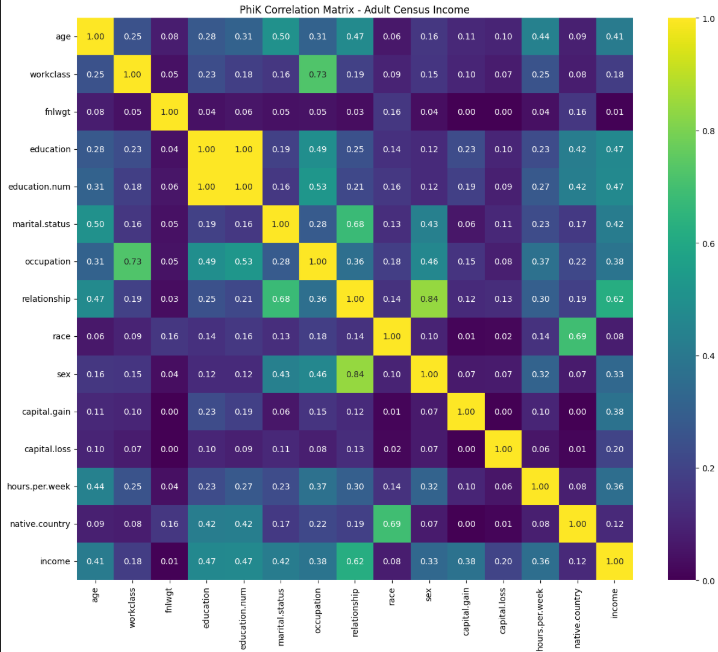

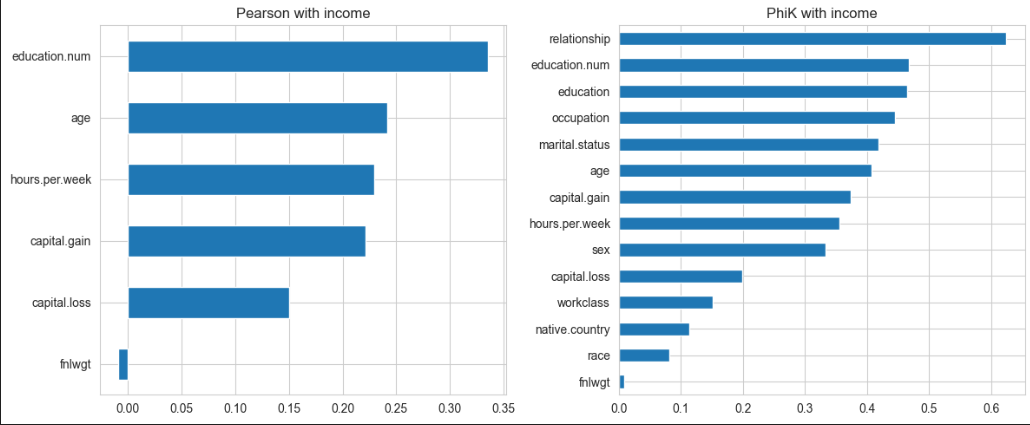

* Linear - Only education.num shows moderate linearity with income. age, hours.per.week and capital.gain are weak, and fnlwgt is about 0.

* Non-linear - PhiK finds much stronger relationships. relationship (0.62), education (0.47), occupation (0.45) and marital.status (0.42) lead. age, capital.gain and hours.per.week also score higher than in Pearson, so their effect on income is non-linear.

* Noise and multi-collinearity - education and education.num are identical (PhiK 1.0), and relationship overlaps with sex (0.84) and marital.status (0.68). fnlwgt has no relationship with income, so it is noise. I plan to drop education.num or education, and fnlwgt, and keep one of the overlapping relationship columns.

* Other - The gap between PhiK and Pearson shows that linear methods would miss to detect the variable that are strongly related with target variable, so models like Phik are worth using. sex and relationship also raise a fairness concern, since they can act as proxies.

##### <b> <u>Step 3e</u>: Feature importances</b> 

<i>
Which features seem to be the most important to your target variable?

<br>

How did you come to this conclusion? 
 
Should any of the variables be removed/dropped, or do they need further processing?

<br>

<u><b>Hint:</b></u> Correlation + PhiK matrices, SelectKBest, Fisher Score, RFE ...

</i>


<br>
<br><br>

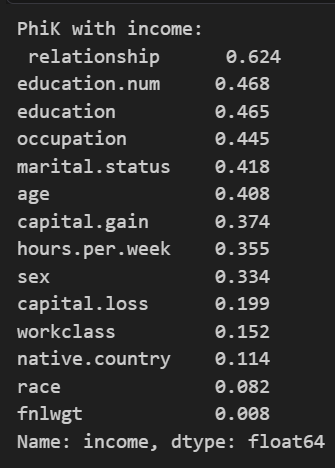 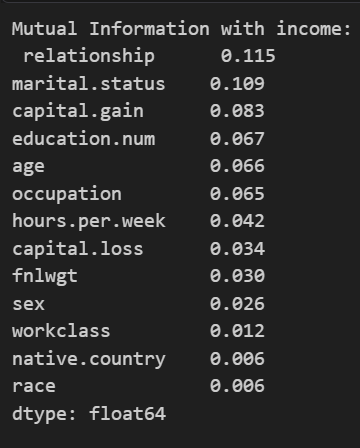

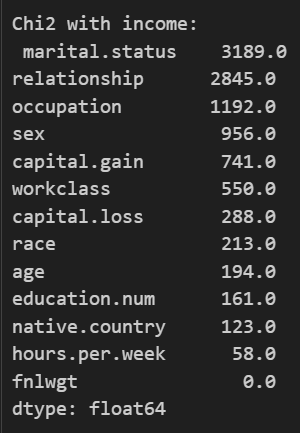 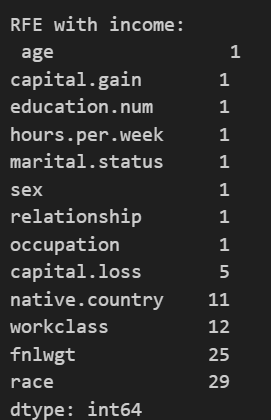

* relationship, marital.status, education.num, occupation, age and capital.gain are the most important features. I came to this using correlation, PhiK, SelectKBest (mutual information and chi2) and RFE with logistic regression, and they largely agree. I skipped the Fisher score because it only captures linear differences. fnlwgt has no signal in any method and should be dropped. race, native.country and workclass are weak and can be dropped or grouped. education duplicates education.num, and relationship overlaps with marital.status and sex, so I will keep only one of each overlapping group. The capital columns should become binary.

##### <b> <u>Step 3f</u>: Other potential problems or issues in the dataset? </b>

<i>
If you found anything else that is worth mentioning, and it isn’t found in the previous checklists, you can also elaborate on these for extra points.

<br>

This usually involves limitations in the datasets, weird behavior (e.g. doesn’t make sense from the common sense point of view) or something similar.



</i>

* The dataset reflects real-world bias that a model would learn. Men are 68% of the rows and 85% of the >50K group (31% of the men earn >50K, against 11% of women). Droping sex is not enough as it have multicolinearity with relationship (Phik-0.84), and therefore model can still discriminate indirectly. The data is also dominated by White (86%) and US-born (91%) people and comes from the 1994 US census, so results for small groups are unreliable and may not generalise to today. Because of this I would report per-group metrics (for example recall by sex), not just overall accuracy, and treat any model built on this data with caution. 

---

### Summary of findings


<i> Please summarize all of the major findings and issues here briefly. A paragraph or two is fine. Lists are also OK.

</i>

The Adult Income dataset (30,139 rows after removing the duplicates and rows with missing ? values) is a classification problem with 75/25 imbalance towards <=50K, so accuracy alone would be misleading and precision, recall and stratified sampling are needed. The main data quality issues are structural, not the data errors. education and education.num are the same information. Also found that fnlwgt is a sampling weight with no relationship to income. capital gain/loss are 91% and 95% zeros, with 148 rows capped at 99,999. With outlier checks, we found the values that are real and plausible, and they are linked to higher income, so I kept them. Many categorical columns like native.country have many rare levels that will need grouping. 

The strongest variables, acoording to all matrices are relationship, martial,status, education.num, occupation, age and capital.gain. Phik also captured the non-linear relationship of the variables with the target and therefore its values are clearly higher than pearson which missed to see the non-linearity. relationship overlaps with sex and martial.status, so I would see wether to keep all the three. The data also carries bias: 68% of the rows are male and 85% of the >50K group is male, and relationship can act as a proxy for sex. While cleaning the data, I would drop fnlwgt and one of the education columns, turn the capital gain/loss columns into binary, group rare categories, and evaluate by group, not only overall.

Note: Although I have mentioned the usage of AI at evry step and how I used it. But I would still like to mention that the AI's help has been taken to generate me the code for better and clear visuals which was cross-checked with prof's code and understood by me. I also took the help of AI to understand the meaning of code, usage of tools and general questions whcih kept on popping while I was doing this massive assignment.

---

##  Advanced tasks (optional, but extra points)

<br>
<br>

##### <b> <u>Step 4a</u>: Under-representation of combinatory categories</b> 

<i>
Are there any combinations of values which are exceptionally rare?

<br>

Example: A client for a bank might have a 18 year old customer with a 23 million Euro outstanding balance. 

Why are they rare? Do you expect these to be problematic? Could they be removed with minor repercussions?

<u><b>Hint:</b></u> Apriori

</i>

<br>
<br><br>

##### <b> <u>Step 4b</u>: Feature creation & derived features</b>

<i>
Can you combine features using operations (+, -, /, *) to make them more useful?

<br>

 Which features would you combine, how, and why?

Example: Credit lenders & debt / income ratio.
Example: Measurable speed – Km / hour

<br>

<u><b>Hint:</u></b> Sometimes, there just isn’t a clear combination of features that makes sense to add to your dataset. However, this problem is mitigated by other tools later in the course.


</i>

<br>
<br><br>

##### <b> <u>Step 4c</u>: Trends between features</b> 

<i>

What can you find when looking at the trends between the features of your dataset?
<br>

Are you noticing some interesting connections and trends?

Could there be some hidden value behind certain features that a machine learning model might find hard to see?
 
<br>

<u><b>Example:</b></u> House condition --> House quality -->  Price

<br>

Does any redundancy exist between these features?

Do you believe this trend would make a negative impact on your model?

Please show visuals of the most interesting feature-feature trends (scatterplot, regplot)

Which tool(s) did you use to inspect this?

<br>

<u><b>Hint:</b></u> You will find these especially (but are not limited to) in time-series data. Seaborn.regplots with hue are really useful here

<br>
<br><br>

</i>

##### <b><u>Step 4d</u>: Conventional EDA vs. tools </b>

<i>
Verify that the results in the tools are correct by using the conventional data-analytics skillset in Python. 

<br>

Use manual EDA (Exploratory Data Analysis), or in other words, <u>all the previous skills you have learnt in earlier data analytics studies.</u>

Verify with pandas features and seaborn visualizations and make sure the analysis of these tools are actually correct.

Are there any contradictions between the the new tools you've used and your own analysis?

<br><br>


##### <b> <u>Step 4e</u>: Non-linear connections / polynomial trends </b>

<i>
One of the features the evaluation tools have difficulties with is visualizing any non-linear connections in a dataset.

<br>

Seaborn, and its regression plot function, has a feature that supports polynomial regression as well.

For the most complicated pairs of variables, try using polynomial regression plots in your dataset and analyze the amount of noise, outliers and complexity your data might have.

</i>